In [235]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt 

from sklearn.cluster import KMeans, DBSCAN
from pathlib import Path
from scipy.spatial.distance import cdist


In [236]:
basin_stca_path = Path("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")

basin_stca_gdf = gpd.read_file(basin_stca_path)
basin_stca_gdf.set_index("ID", inplace=True)

In [237]:
no_na_df = basin_stca_gdf.dropna().sort_index()
numeric_df = no_na_df.select_dtypes(include=["number"])

Text(0.5, 1.0, 'Elbow mehtod with inertia')

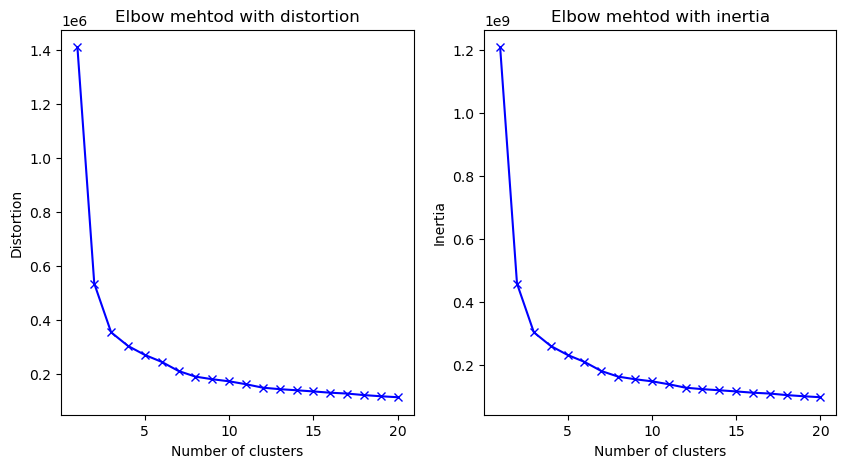

In [238]:
distortions = []
inertias = []
K = range(1,21)

for k in K:
    kmeans_test = KMeans(n_clusters=k, random_state=42).fit(numeric_df)
    distortions.append(sum(np.min(cdist(numeric_df, kmeans_test.cluster_centers_, 'euclidean'), axis=1)**2) / len(numeric_df))
    inertias.append(kmeans_test.inertia_)

fig, axs = plt.subplots(1,2, figsize=(10,5))

axs[0].plot(K,distortions,"bx-")
axs[0].set_xlabel("Number of clusters")
axs[0].set_ylabel("Distortion")
axs[0].set_title("Elbow mehtod with distortion")

axs[1].plot(K,inertias,"bx-")
axs[1].set_xlabel("Number of clusters")
axs[1].set_ylabel("Inertia")
axs[1].set_title("Elbow mehtod with inertia")


In [239]:
kmeans = KMeans(n_clusters=5, random_state=42)

kmeans.fit(numeric_df)

basin_labels = dict(zip(numeric_df.index,kmeans.labels_))

In [240]:
plot_gdf = no_na_df.copy()
plot_gdf["cluster"] = basin_labels.values()

<Axes: >

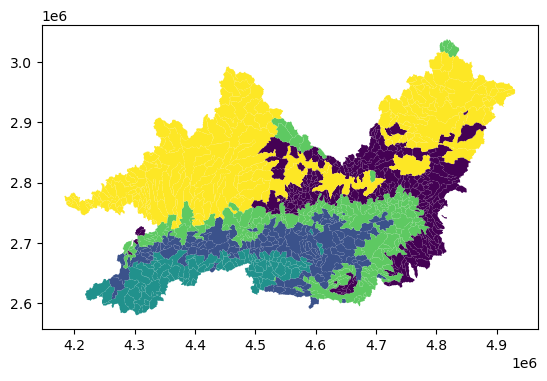

In [241]:
plot_gdf.plot(column="cluster")